# Configuration

In [38]:
!uv pip install datasets spacy wordcloud textstat

Using Python 3.11.12 environment at: /usr
Resolved 78 packages in 752ms
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
textstat   ------------------------------     0 B/102.83 KiB
⠙ Preparing packages... (0/3)
textstat   ------------------------------ 16.00 KiB/102.83 KiB
⠙ Preparing packages... (0/3)
textstat   ------------------------------ 32.00 KiB/102.83 KiB
⠙ Preparing packages... (0/3)
textstat   ------------------------------ 48.00 KiB/102.83 KiB
⠙ Preparing packages... (0/3)
textstat   ------------------------------ 64.00 KiB/102.83 KiB
⠙ Preparing packages... (0/3)
textstat   ------------------------------ 80.00 KiB/102.83 KiB
⠙ Preparing packages... (0/3)
textstat   ------------------------------ 96.00 KiB/102.83 KiB
⠙ Preparing packages... (0/3)
textstat   ------------------------------ 96.00 KiB/102.83 KiB
cmudict    ------------------------------     0 B/917.39 KiB
⠙ Preparing packages... (0/3)
textstat   ------------------------------ 96.00 KiB/102.83 KiB
cm

In [2]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 137.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [40]:
import enum
import random

import spacy
import textstat
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from wordcloud import WordCloud

In [4]:
class Datasets(enum.Enum):
    elife = "BioLaySumm/BioLaySumm2025-eLife"
    plos = "BioLaySumm/BioLaySumm2025-PLOS"


plos_dataset = load_dataset(Datasets.plos.value)
elife_dataset = load_dataset(Datasets.elife.value)

README.md:   0%|          | 0.00/693 [00:00<?, ?B/s]

train-00000-of-00003.parquet:   0%|          | 0.00/169M [00:00<?, ?B/s]

train-00001-of-00003.parquet:   0%|          | 0.00/170M [00:00<?, ?B/s]

train-00002-of-00003.parquet:   0%|          | 0.00/169M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/28.2M [00:00<?, ?B/s]

...

validation-00000-of-00001.parquet:   0%|          | 0.00/6.92M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/3.27M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4346 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/241 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/142 [00:00<?, ? examples/s]

# Functions

In [61]:
spacy.require_gpu()
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
nlp.add_pipe("sentencizer")
sns.set_theme(style="whitegrid")


def text_statistics(text: str):
    doc = nlp(text)
    num_tokens = len(doc)
    num_sentences = len(list(doc.sents))
    avg_sent_len = (
        np.mean([len(sent) for sent in doc.sents]) if num_sentences > 0 else 0
    )

    return num_tokens, num_sentences, avg_sent_len


def batch_column_statistics(samples: list, column: str):
    tokens, sentences, avg = [], [], []

    for text in samples[column]:
        n_tokens, n_sentences, avg_sent_len = text_statistics(text)
        tokens.append(n_tokens)
        sentences.append(n_sentences)
        avg.append(avg_sent_len)

    return {
        f"{column}_tokens": tokens,
        f"{column}_sentences": sentences,
        f"{column}_avg_sent_len": avg,
    }


def readability_scores(text: str):
    fre = textstat.flesch_reading_ease(text)
    fkg = textstat.flesch_kincaid_grade(text)

    return fre, fkg


def batch_readability_scores(examples, column: str):
    fre_scores, fkg_scores = [], []
    for txt in examples[column]:
        fre, fkg = readability_scores(txt)
        fre_scores.append(fre)
        fkg_scores.append(fkg)

    return {
        f"{column}_flesch_reading_ease": fre_scores,
        f"{column}_flesch_kincaid_grade": fkg_scores,
    }


def analyse_dataset(dataset):
    for split in ["train", "validation", "test"]:
        for column in ["article", "summary", "title"]:
            dataset[split] = dataset[split].map(
                lambda sample: batch_column_statistics(sample, column),
                batched=True,
                batch_size=2048,
            )

        dataset[split] = dataset[split].map(
            lambda sample: batch_readability_scores(sample, "summary"),
            batched=True,
            batch_size=2048,
        )


def plot_wordcloud(texts: list[str]):
    all_text = " ".join(texts)
    wc = WordCloud(width=800, height=400, background_color="white").generate(all_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()


def concat_splits(dataset, splits: list[str]):
    dfs = []
    for split in splits:
        df = dataset[split].to_pandas()
        df["split"] = split
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


def plot_dataset_statistics(dataset):
    df = concat_splits(dataset, ["train", "validation", "test"])

    def melt_column(metric):
        cols = [f"{field}_{metric}" for field in ["article", "summary", "title"]]
        long = df[["split"] + cols].melt(
            id_vars="split", value_vars=cols, var_name="field", value_name=metric
        )
        long["field"] = long["field"].str.replace(f"_{metric}", "")

        return long

    tokens = melt_column("tokens")
    sentences = melt_column("sentences")
    avg_sentences = melt_column("avg_sent_len")

    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
    fields = ["article", "summary", "title"]

    for i, fld in enumerate(fields):
        # Token counts (left column)
        ax1 = axes[i, 0]
        sns.boxplot(
            data=tokens[tokens.field == fld],
            x="split",
            y="tokens",
            hue="split",
            dodge=False,
            showfliers=False,
            ax=ax1,
        )
        ax1.set_title(f"{fld.title()} Token Counts by Split")
        ax1.set_ylabel("Number of Tokens")
        ax1.set_xlabel("Split")

        # Sentence counts (right column)
        ax2 = axes[i, 1]
        sns.boxplot(
            data=sentences[sentences.field == fld],
            x="split",
            y="sentences",
            hue="split",
            dodge=False,
            showfliers=False,
            ax=ax2,
        )
        ax2.set_title(f"{fld.title()} Sentence Counts by Split")
        ax2.set_ylabel("Number of Sentences")
        ax2.set_xlabel("Split")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=avg_sentences, x="field", y="avg_sent_len", hue="split", showfliers=False
    )
    plt.title("Average Sentence Length by Field & Split")
    plt.ylabel("Tokens per Sentence")
    plt.xlabel("Field")
    plt.legend(title="Split")
    plt.tight_layout()
    plt.show()


def plot_readability_scores(dataset):
    df = concat_splits(dataset, ["train", "validation"])
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

    # Flesch Reading Ease
    sns.histplot(
        data=df,
        x="summary_flesch_reading_ease",
        hue="split",
        bins=20,
        ax=axes[0, 0],
        element="step",
        stat="count",
        common_norm=False,
    )
    axes[0, 0].set_title("Distribution of Flesch Reading Ease")
    axes[0, 0].set_xlabel("Flesch Reading Ease (higher = easier)")
    axes[0, 0].set_ylabel("Count")

    # Flesch–Kincaid Grade Level
    sns.histplot(
        data=df,
        x="summary_flesch_kincaid_grade",
        hue="split",
        bins=20,
        ax=axes[0, 1],
        element="step",
        stat="count",
        common_norm=False,
    )
    axes[0, 1].set_title("Distribution of Flesch–Kincaid Grade Level")
    axes[0, 1].set_xlabel("Grade Level (U.S. school)")
    axes[0, 1].set_ylabel("Count")

    # FRE vs. Avg. Sentence Length
    sns.scatterplot(
        data=df,
        x="summary_avg_sent_len",
        y="summary_flesch_reading_ease",
        hue="split",
        ax=axes[1, 0],
        alpha=0.6,
        s=40,
    )
    axes[1, 0].set_title("Flesch Reading Ease vs. Avg. Sentence Length")
    axes[1, 0].set_xlabel("Average Sentence Length (tokens)")
    axes[1, 0].set_ylabel("Flesch Reading Ease")

    # FKG Grade vs. Avg. Sentence Length
    sns.scatterplot(
        data=df,
        x="summary_avg_sent_len",
        y="summary_flesch_kincaid_grade",
        hue="split",
        ax=axes[1, 1],
        alpha=0.6,
        s=40,
    )
    axes[1, 1].set_title("FKG Grade vs. Avg. Sentence Length")
    axes[1, 1].set_xlabel("Average Sentence Length (tokens)")
    axes[1, 1].set_ylabel("Flesch–Kincaid Grade Level")

    plt.tight_layout()
    plt.show()


# eLife Text Analysis

In [12]:
elife_dataset

DatasetDict({
    train: Dataset({
        features: ['article', 'summary', 'section_headings', 'keywords', 'year', 'title'],
        num_rows: 4346
    })
    validation: Dataset({
        features: ['article', 'summary', 'section_headings', 'keywords', 'year', 'title'],
        num_rows: 241
    })
    test: Dataset({
        features: ['article', 'summary', 'section_headings', 'keywords', 'year', 'title'],
        num_rows: 142
    })
})

In [17]:
analyse_dataset(elife_dataset)

Map:   0%|          | 0/4346 [00:00<?, ? examples/s]

Map:   0%|          | 0/4346 [00:00<?, ? examples/s]

Map:   0%|          | 0/4346 [00:00<?, ? examples/s]

Map:   0%|          | 0/241 [00:00<?, ? examples/s]

Map:   0%|          | 0/241 [00:00<?, ? examples/s]

Map:   0%|          | 0/241 [00:00<?, ? examples/s]

Map:   0%|          | 0/142 [00:00<?, ? examples/s]

Map:   0%|          | 0/142 [00:00<?, ? examples/s]

Map:   0%|          | 0/142 [00:00<?, ? examples/s]

In [55]:
elife_dataset

DatasetDict({
    train: Dataset({
        features: ['article', 'summary', 'section_headings', 'keywords', 'year', 'title', 'article_tokens', 'article_sentences', 'article_avg_sent_len', 'summary_tokens', 'summary_sentences', 'summary_avg_sent_len', 'title_tokens', 'title_sentences', 'title_avg_sent_len', 'summary_flesch_reading_ease', 'summary_flesch_kincaid_grade'],
        num_rows: 4346
    })
    validation: Dataset({
        features: ['article', 'summary', 'section_headings', 'keywords', 'year', 'title', 'article_tokens', 'article_sentences', 'article_avg_sent_len', 'summary_tokens', 'summary_sentences', 'summary_avg_sent_len', 'title_tokens', 'title_sentences', 'title_avg_sent_len', 'summary_flesch_reading_ease', 'summary_flesch_kincaid_grade'],
        num_rows: 241
    })
    test: Dataset({
        features: ['article', 'summary', 'section_headings', 'keywords', 'year', 'title', 'article_tokens', 'article_sentences', 'article_avg_sent_len', 'summary_tokens', 'summary_senten

## Statistics

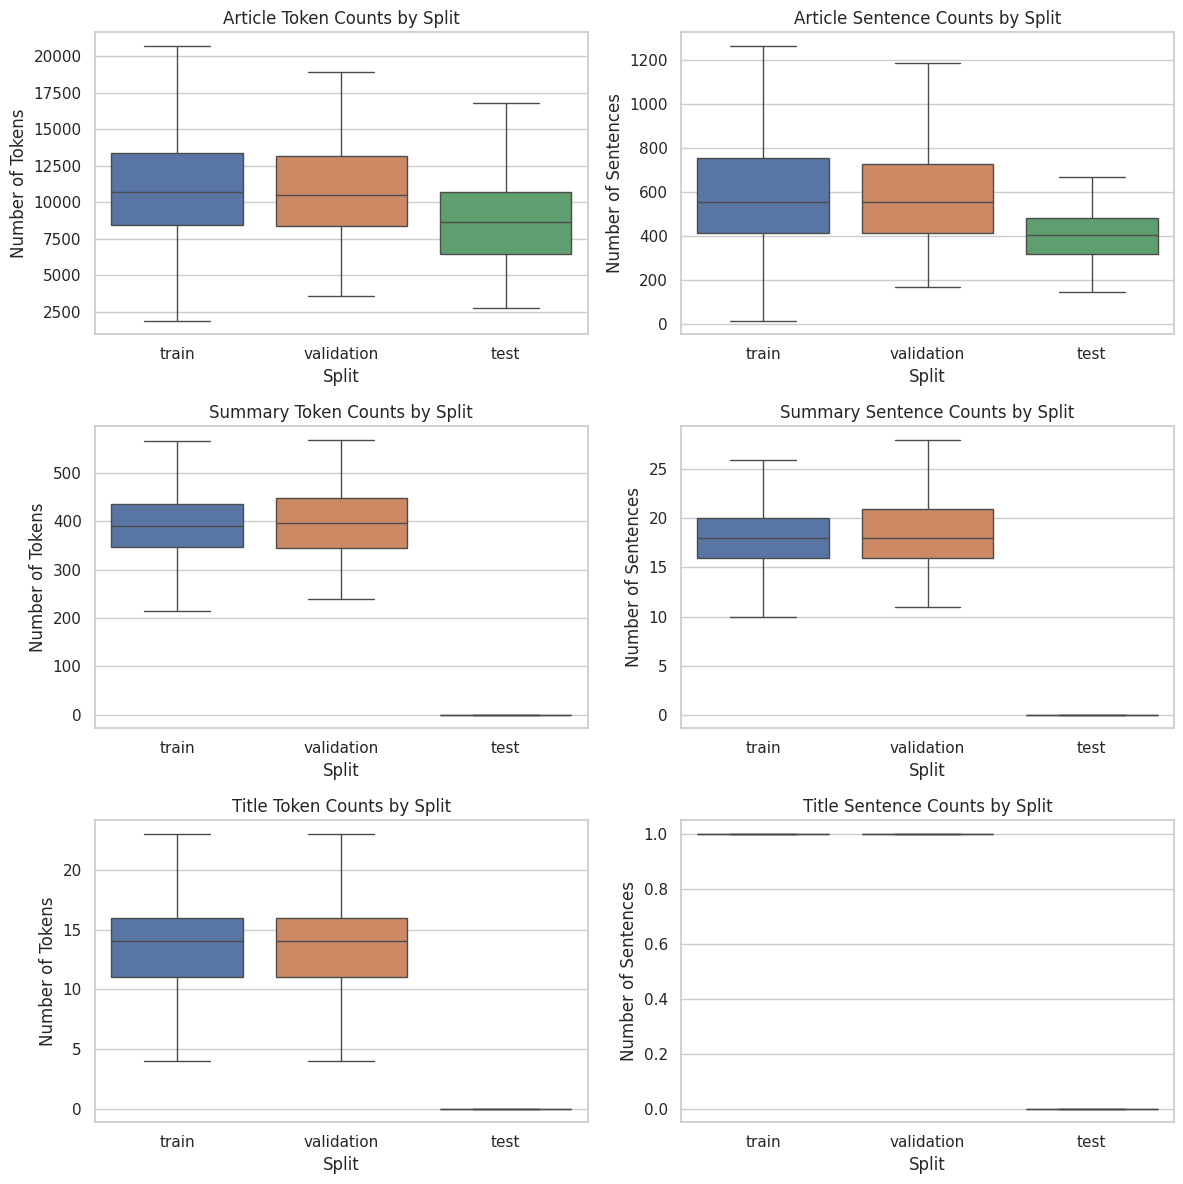

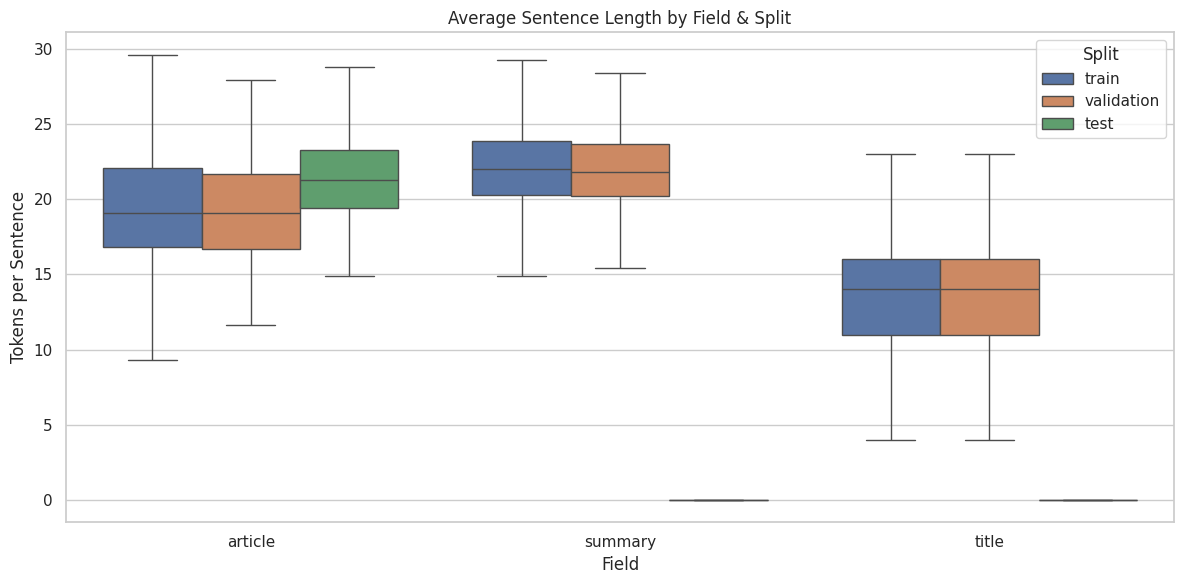

In [62]:
plot_dataset_statistics(elife_dataset)

## Readability

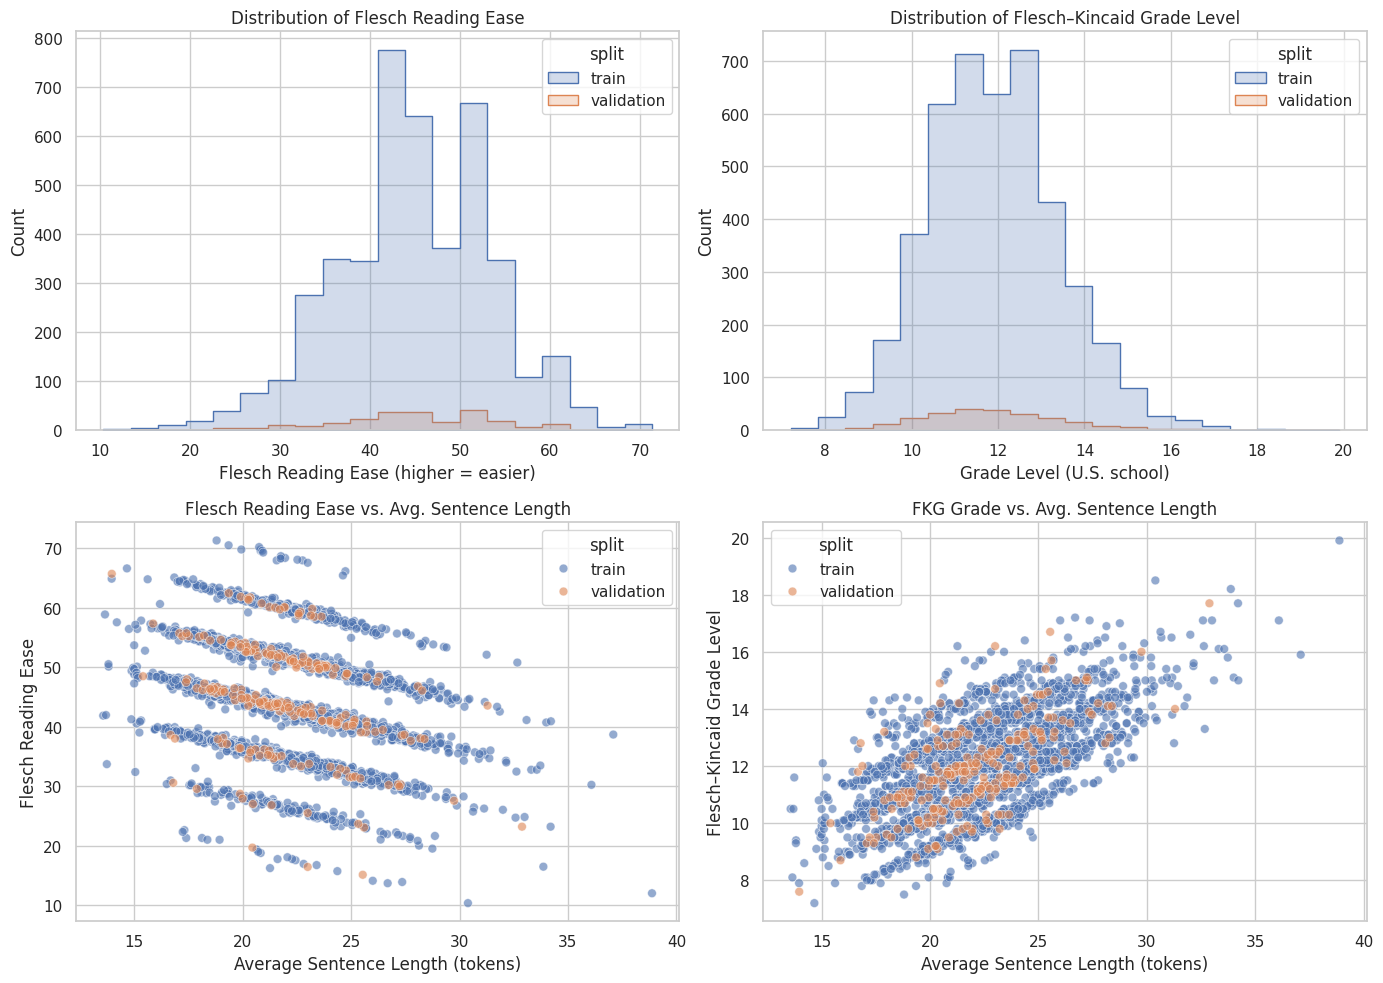

In [63]:
plot_readability_scores(elife_dataset)

## Word Clouds

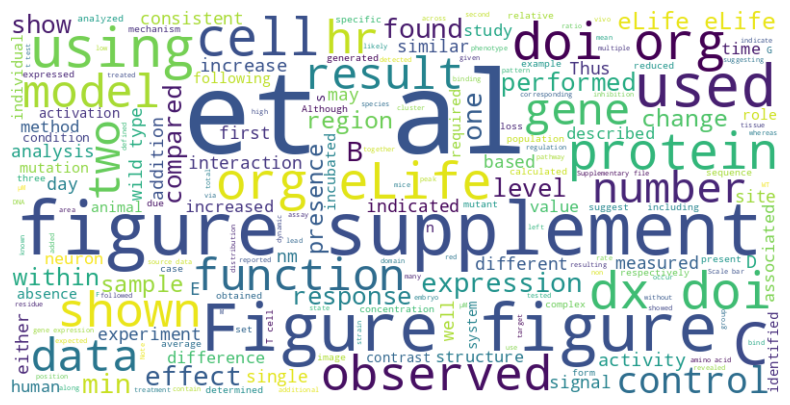

In [64]:
plot_wordcloud(random.sample(elife_dataset["train"]["article"], 500))

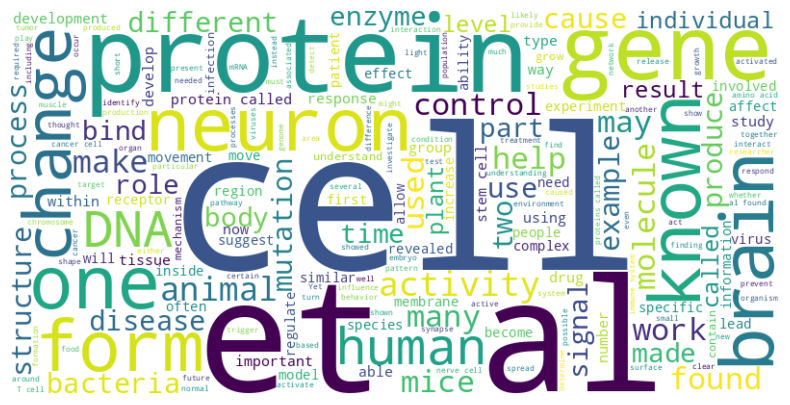

In [65]:
plot_wordcloud(elife_dataset["train"]["summary"])

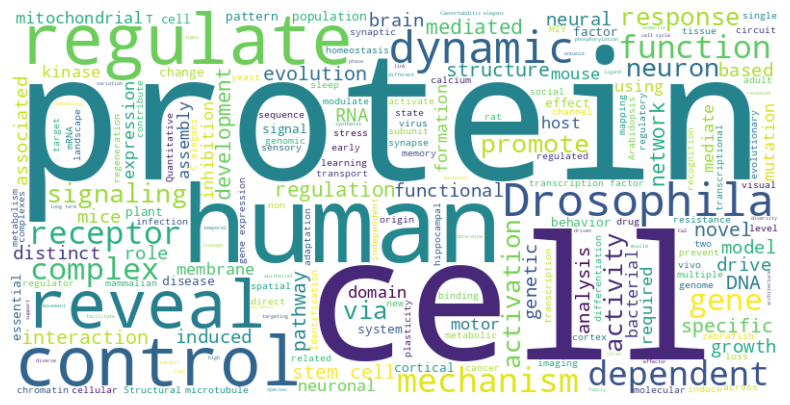

In [66]:
plot_wordcloud(elife_dataset["train"]["title"])

# PLOS Text Analysis

In [51]:
plos_dataset

DatasetDict({
    train: Dataset({
        features: ['article', 'summary', 'section_headings', 'keywords', 'year', 'title'],
        num_rows: 24773
    })
    validation: Dataset({
        features: ['article', 'summary', 'section_headings', 'keywords', 'year', 'title'],
        num_rows: 1376
    })
    test: Dataset({
        features: ['article', 'summary', 'section_headings', 'keywords', 'year', 'title'],
        num_rows: 142
    })
})

In [53]:
analyse_dataset(plos_dataset)

Map:   0%|          | 0/24773 [00:00<?, ? examples/s]

Map:   0%|          | 0/24773 [00:00<?, ? examples/s]

Map:   0%|          | 0/24773 [00:00<?, ? examples/s]

Map:   0%|          | 0/24773 [00:00<?, ? examples/s]

Map:   0%|          | 0/1376 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/1376 [00:00<?, ? examples/s]

Map:   0%|          | 0/142 [00:00<?, ? examples/s]

Map:   0%|          | 0/142 [00:00<?, ? examples/s]

Map:   0%|          | 0/142 [00:00<?, ? examples/s]

Map:   0%|          | 0/142 [00:00<?, ? examples/s]

In [54]:
plos_dataset

DatasetDict({
    train: Dataset({
        features: ['article', 'summary', 'section_headings', 'keywords', 'year', 'title', 'article_tokens', 'article_sentences', 'article_avg_sent_len', 'summary_tokens', 'summary_sentences', 'summary_avg_sent_len', 'title_tokens', 'title_sentences', 'title_avg_sent_len', 'summary_flesch_reading_ease', 'summary_flesch_kincaid_grade'],
        num_rows: 24773
    })
    validation: Dataset({
        features: ['article', 'summary', 'section_headings', 'keywords', 'year', 'title', 'article_tokens', 'article_sentences', 'article_avg_sent_len', 'summary_tokens', 'summary_sentences', 'summary_avg_sent_len', 'title_tokens', 'title_sentences', 'title_avg_sent_len', 'summary_flesch_reading_ease', 'summary_flesch_kincaid_grade'],
        num_rows: 1376
    })
    test: Dataset({
        features: ['article', 'summary', 'section_headings', 'keywords', 'year', 'title', 'article_tokens', 'article_sentences', 'article_avg_sent_len', 'summary_tokens', 'summary_sent

## Statistics

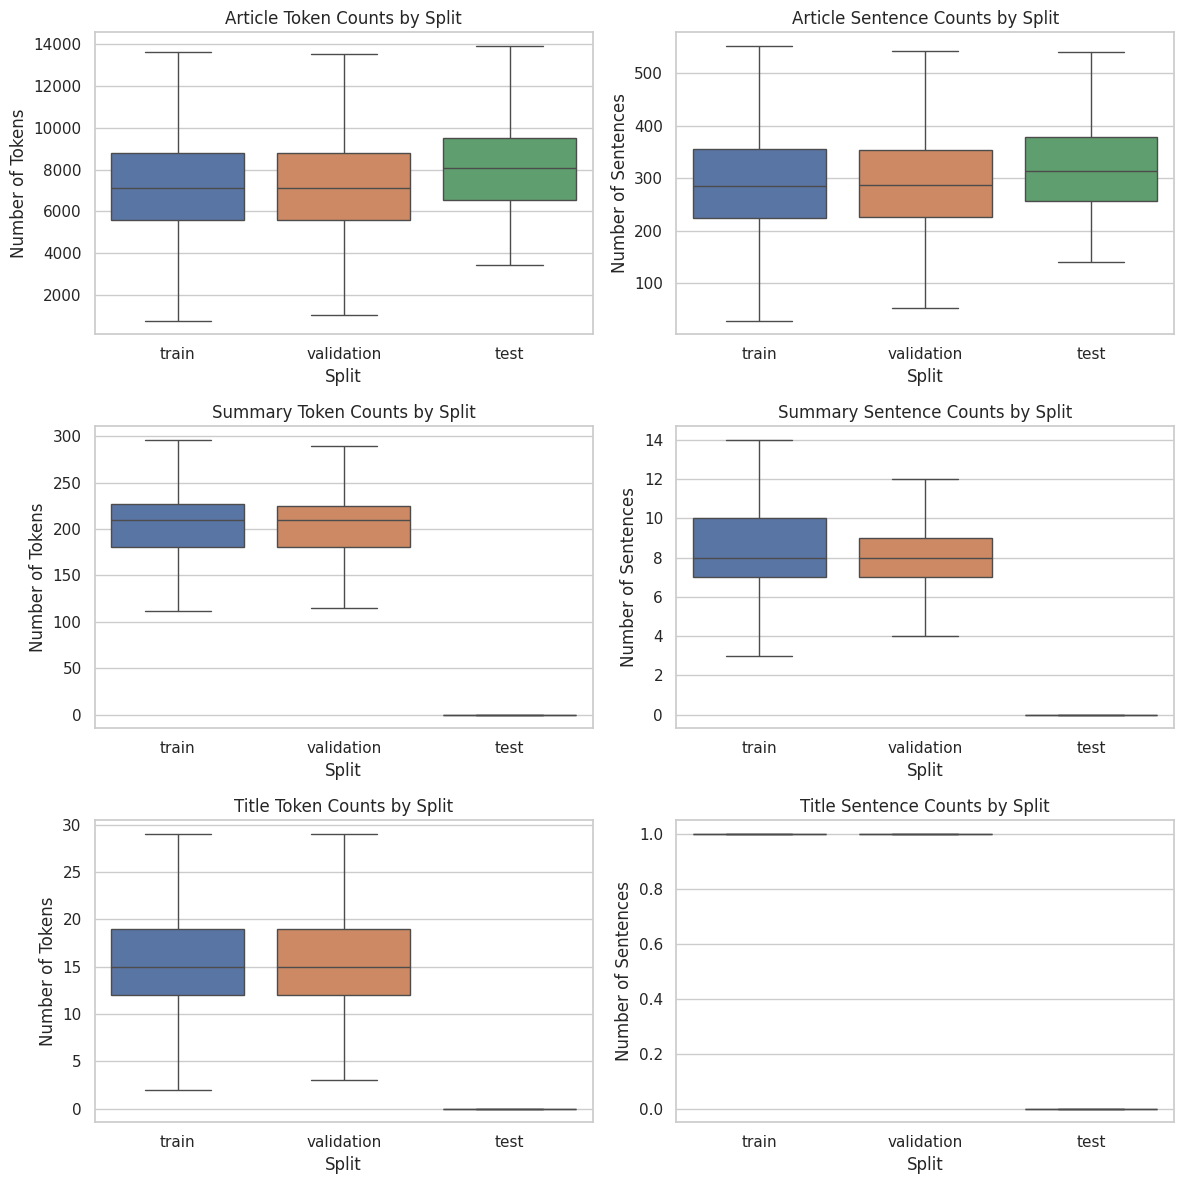

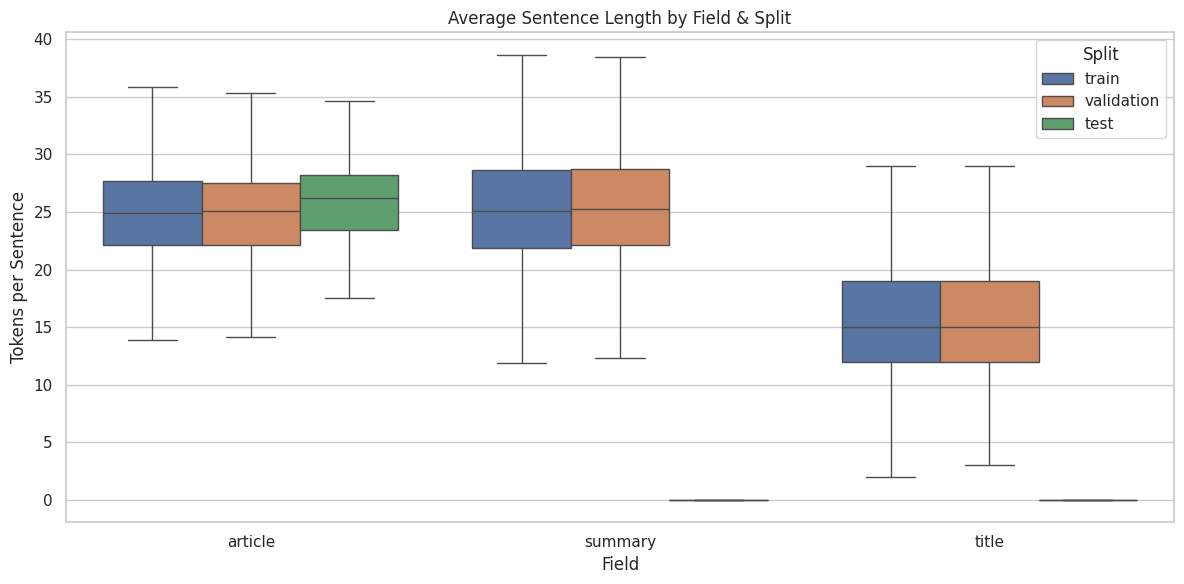

In [67]:
plot_dataset_statistics(plos_dataset)

## Readability

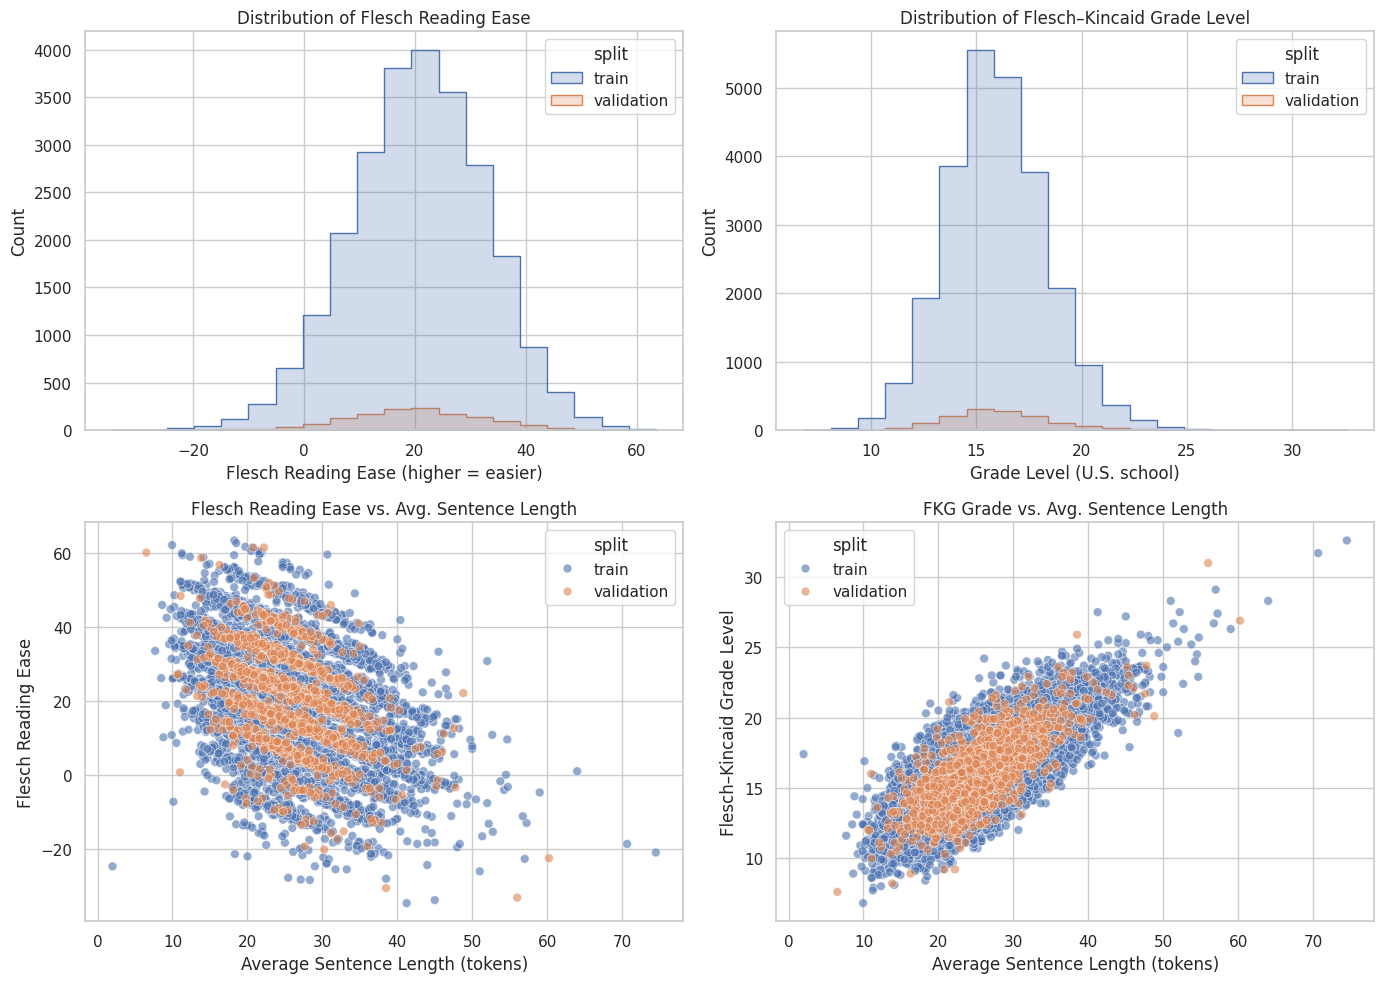

In [68]:
plot_readability_scores(plos_dataset)

## Word Clouds

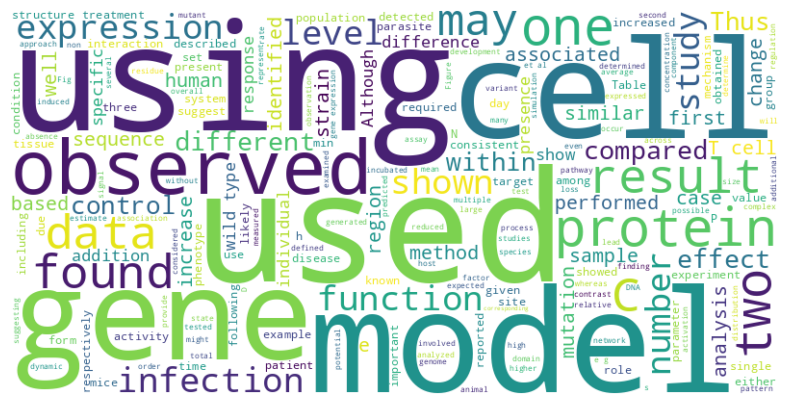

In [69]:
plot_wordcloud(random.sample(plos_dataset["train"]["article"], 500))

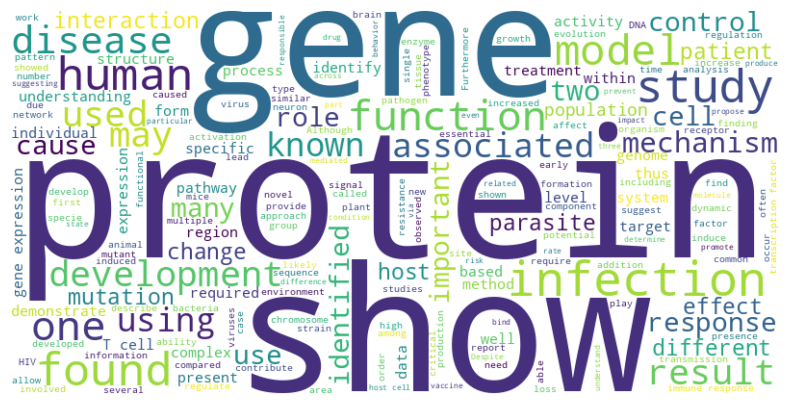

In [70]:
plot_wordcloud(plos_dataset["train"]["summary"])

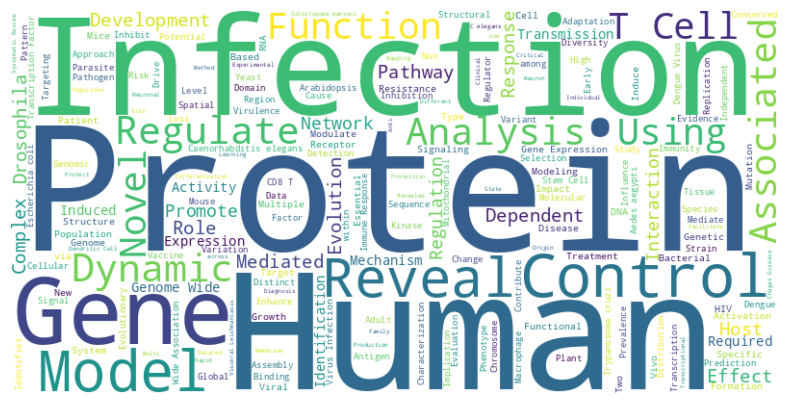

In [71]:
plot_wordcloud(plos_dataset["train"]["title"])